# Project 3

**University:** Amir Kabir University of Technology (Tehran Polytechnic)

**Course:** Mathematical Software

**Student:** Parsa Nasiri

**Student Number:** 40212047

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline
from scipy.integrate import trapezoid, simpson, fixed_quad, quad

import sympy as sp

plt.style.use("default")

# Question 1

## Lagrange and Cubic Spline Interpolation

In this section, the given data points are interpolated using the Lagrange polynomial and Cubic Spline methods. The resulting interpolation functions are obtained and compared graphically.

### Given Data Points

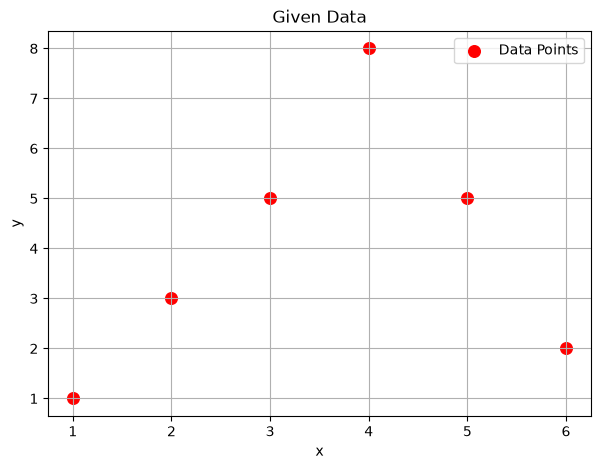

In [107]:
x = np.array([1, 2, 3, 4, 5, 6], dtype=float)
y = np.array([1, 3, 5, 8, 5, 2], dtype=float)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, color="red", s=70, label="Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Given Data")
plt.grid(True)
plt.legend()
plt.show()

### Lagrange Polynomial

In [108]:
X = sp.Symbol("x")

points = list(zip(x, y))

lagrange_poly = sp.interpolate(points, X)

sp.expand(lagrange_poly)

0.175*x**5 - 2.95833333333333*x**4 + 18.375*x**3 - 52.0416666666666*x**2 + 68.45*x - 31.0

### Polynomial Visualization

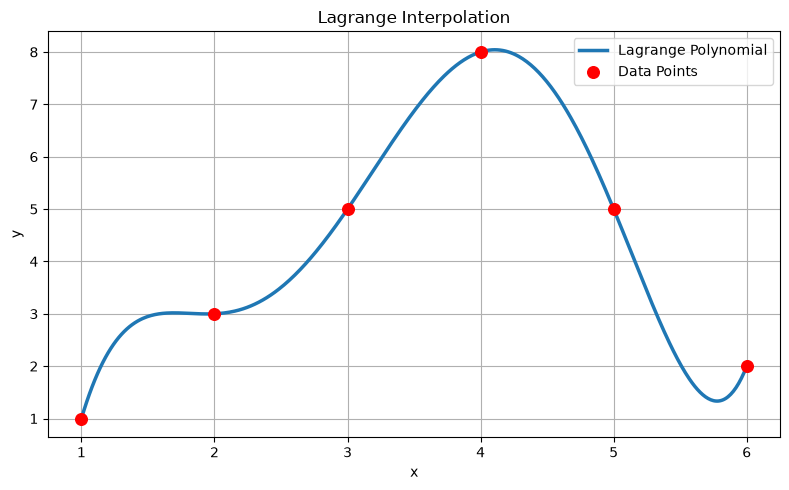

In [109]:
lagrange_function = sp.lambdify(X, lagrange_poly, "numpy")

x_plot = np.linspace(1, 6, 500)
y_plot = lagrange_function(x_plot)

plt.figure(figsize=(8, 5))

plt.plot(x_plot, y_plot, linewidth=2.5, label="Lagrange Polynomial")
plt.scatter(x, y, color="red", s=70, zorder=3, label="Data Points")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Lagrange Interpolation")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("../figures/lagrange.png", dpi=300)

plt.show()

### Cubic Spline Interpolation

In [110]:
spline = CubicSpline(x, y)

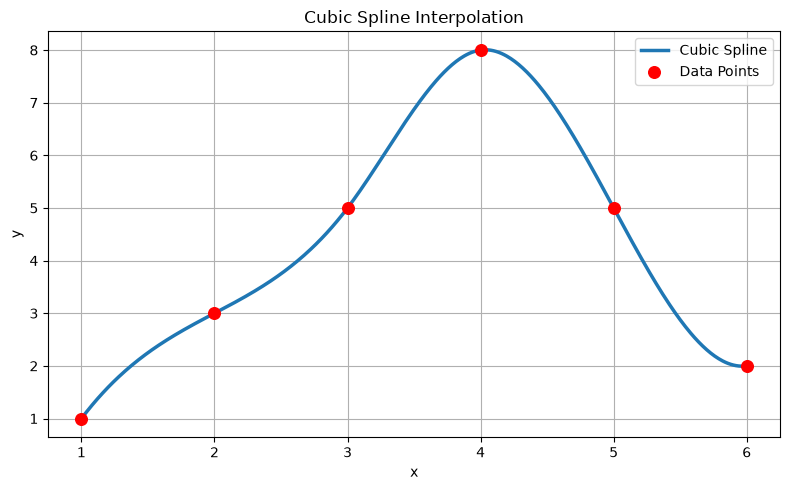

In [111]:
x_plot = np.linspace(1, 6, 500)
y_spline = spline(x_plot)

plt.figure(figsize=(8, 5))

plt.plot(x_plot, y_spline, linewidth=2.5, label="Cubic Spline")
plt.scatter(x, y, color="red", s=70, zorder=3, label="Data Points")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Cubic Spline Interpolation")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("../figures/spline.png", dpi=300)

plt.show()

### Comparison of Interpolation Methods

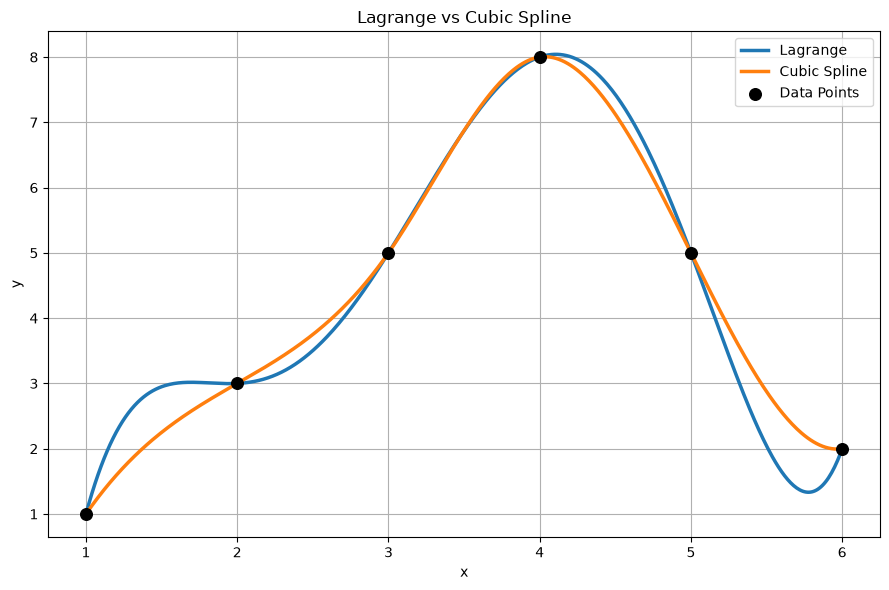

In [112]:
y_lagrange = lagrange_function(x_plot)

plt.figure(figsize=(9, 6))

plt.plot(x_plot, y_lagrange, linewidth=2.5, label="Lagrange")
plt.plot(x_plot, y_spline, linewidth=2.5, label="Cubic Spline")

plt.scatter(x, y, color="black", s=70, zorder=3, label="Data Points")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Lagrange vs Cubic Spline")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("../figures/interpolation_comparison.png", dpi=300)

plt.show()

### Piecewise Cubic Spline Functions

In [113]:
for i in range(len(x) - 1):
    a, b, c, d = spline.c[:, i]

    polynomial = (
        a * (X - x[i])**3 +
        b * (X - x[i])**2 +
        c * (X - x[i]) +
        d
    )

    print(f"\nInterval [{x[i]}, {x[i + 1]}]")
    sp.pprint(sp.expand(polynomial))


Interval [1.0, 2.0]
                   3        2                           
0.666666666666666⋅x  - 4.0⋅x  + 9.33333333333333⋅x - 5.0

Interval [2.0, 3.0]
                   3        2                                        
0.666666666666666⋅x  - 4.0⋅x  + 9.33333333333333⋅x - 4.99999999999999

Interval [3.0, 4.0]
                    3         2                            
- 2.33333333333333⋅x  + 23.0⋅x  - 71.6666666666667⋅x + 76.0

Interval [4.0, 5.0]
                  3         2                             
1.66666666666667⋅x  - 25.0⋅x  + 120.333333333333⋅x - 180.0

Interval [5.0, 6.0]
                  3         2                             
1.66666666666667⋅x  - 25.0⋅x  + 120.333333333333⋅x - 180.0


### Summary

In [114]:
summary = pd.DataFrame(
    {
        "Method": ["Lagrange", "Cubic Spline"],
        "Polynomial Form": ["Single Polynomial", "Piecewise Polynomial"],
        "Degree": [len(x) - 1, 3],
        "Interpolation": ["Exact", "Exact"],
    }
)

summary

,Method,Polynomial Form,Degree,Interpolation
0,Lagrange,Single Polynomial,5,Exact
1,Cubic Spline,Piecewise Polynomial,3,Exact


## Conclusion

Both interpolation methods pass exactly through all given data points.

- **Lagrange interpolation** produces a single polynomial of degree 5.
- **Cubic spline interpolation** constructs a piecewise cubic function that is smoother and generally more stable for larger datasets.

# Question 2

## Excel Data Analysis and Visualization

### Load the Excel File

In [115]:
file_path = "../data/پروژه 3.xlsx"

df = pd.read_excel(file_path)

df = df.dropna(how="all").reset_index(drop=True)

df

,Run time for different data size,Alg.1,Alg.2,Alg.3
0,100KB,50,200,100
1,200KB,55,220,200
2,300KB,60,240,300
3,400KB,65,260,400
4,500KB,70,280,500
5,600KB,75,300,600
6,700KB,80,320,700


### Dataset Information

In [116]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

df.info()

Number of rows: 7
Number of columns: 4
<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0    Run time for different data size  7 non-null      str  
 1   Alg.1                              7 non-null      int64
 2   Alg.2                              7 non-null      int64
 3   Alg.3                              7 non-null      int64
dtypes: int64(3), str(1)
memory usage: 356.0 bytes


### Descriptive Statistics

In [117]:
df.describe()

,Alg.1,Alg.2,Alg.3
count,7.000000,7.000000,7.00000
mean,65.000000,260.000000,400.00000
std,10.801234,43.204938,216.02469
min,50.000000,200.000000,100.00000
25%,57.500000,230.000000,250.00000
50%,65.000000,260.000000,400.00000
75%,72.500000,290.000000,550.00000
max,80.000000,320.000000,700.00000


### Bar Chart

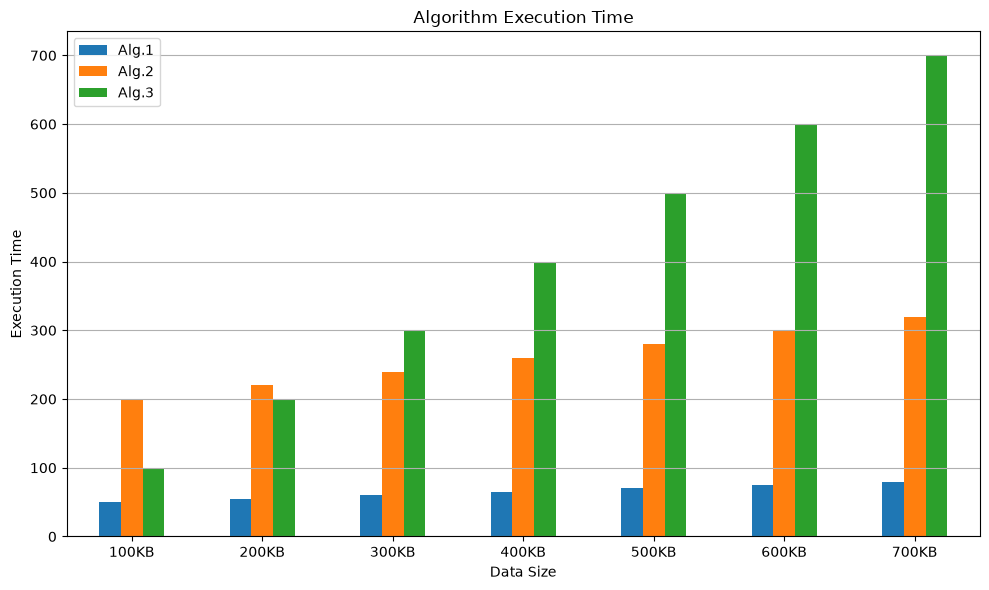

In [118]:
ax = df.plot(
    x=df.columns[0],
    y=df.columns[1:],
    kind="bar",
    figsize=(10, 6),
    rot=0
)

ax.set_title("Algorithm Execution Time")
ax.set_xlabel("Data Size")
ax.set_ylabel("Execution Time")
ax.grid(axis="y")

plt.tight_layout()

plt.savefig("../figures/bar_chart.png", dpi=300)

plt.show()

### Line Chart

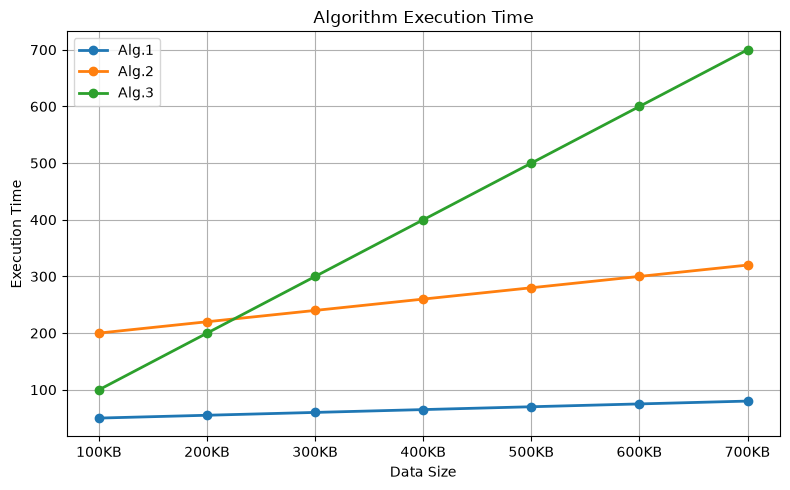

In [119]:
plt.figure(figsize=(8, 5))

for column in df.columns[1:]:
    plt.plot(
        df.iloc[:, 0],
        df[column],
        marker="o",
        linewidth=2,
        label=column
    )

plt.title("Algorithm Execution Time")
plt.xlabel("Data Size")
plt.ylabel("Execution Time")

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("../figures/line_chart.png", dpi=300)

plt.show()

### Box Plot

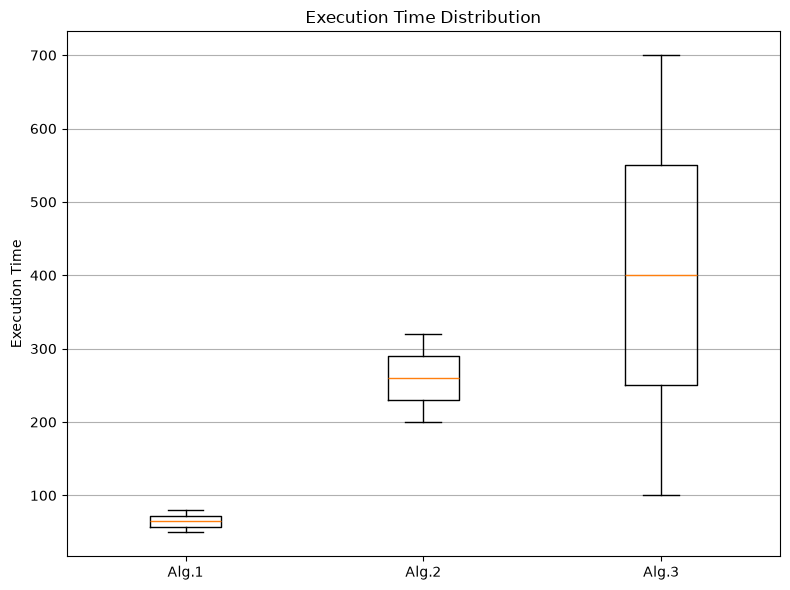

In [120]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [df[column] for column in df.columns[1:]],
    tick_labels=df.columns[1:]
)

plt.title("Execution Time Distribution")
plt.ylabel("Execution Time")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig("../figures/box_plot.png", dpi=300)

plt.show()

### Average Execution Time of Algorithm 2

In [121]:
algorithm_2 = df.iloc[:-1, 2]

average_time = algorithm_2.mean()

print(f"Average execution time of Algorithm 2 (100KB–600KB): {average_time:.2f}")

Average execution time of Algorithm 2 (100KB–600KB): 250.00


# Question 3

## Numerical Integration of $f(x)=e^{x^2}$

In this section, the definite integral


$\int_0^1 e^{x^2}\,dx$


is approximated using three numerical integration methods:

- Trapezoidal Rule
- Simpson's Rule
- Gaussian Quadrature

The obtained results are then compared.

In [122]:
def f(x):
    return np.exp(x**2)

## Function Visualization

The function is plotted over the interval $[0,1]$ before performing numerical integration.

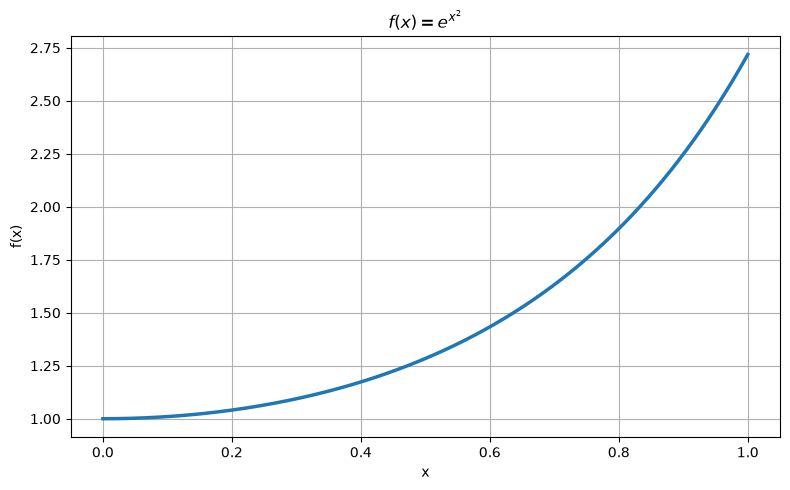

In [123]:
x = np.linspace(0, 1, 500)
y = f(x)

plt.figure(figsize=(8, 5))

plt.plot(x, y, linewidth=2.5)

plt.title(r"$f(x)=e^{x^2}$")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.grid(True)

plt.tight_layout()

plt.savefig("../figures/function_plot.png", dpi=300)

plt.show()

## Trapezoidal Rule

The integral is approximated using the composite trapezoidal rule.

In [124]:
x_values = np.linspace(0, 1, 101)
y_values = f(x_values)

trapezoidal_result = trapezoid(y_values, x_values)

print(f"Trapezoidal Rule: {trapezoidal_result:.10f}")

Trapezoidal Rule: 1.4626970498


## Simpson's Rule

The integral is approximated using the composite Simpson's rule.

In [125]:
simpson_result = simpson(y_values, x_values)

print(f"Simpson's Rule: {simpson_result:.10f}")

Simpson's Rule: 1.4626517489


## Gaussian Quadrature

The integral is approximated using Gaussian Quadrature.

In [126]:
gaussian_result, _ = fixed_quad(f, 0, 1, n=5)

print(f"Gaussian Quadrature: {gaussian_result:.10f}")

Gaussian Quadrature: 1.4626516680


## Accuracy Comparison

The numerical results are compared with a highly accurate reference value obtained using adaptive numerical integration.

In [127]:
reference_value, _ = quad(f, 0, 1)

comparison = pd.DataFrame(
    {
        "Method": [
            "Trapezoidal Rule",
            "Simpson's Rule",
            "Gaussian Quadrature",
        ],
        "Integral Value": [
            trapezoidal_result,
            simpson_result,
            gaussian_result,
        ],
    }
)

comparison["Absolute Error"] = np.abs(
    comparison["Integral Value"] - reference_value
)

comparison

,Method,Integral Value,Absolute Error
0,Trapezoidal Rule,1.462697,4.530394e-05
1,Simpson's Rule,1.462652,3.019752e-09
2,Gaussian Quadrature,1.462652,7.788850e-08
